# Data sources

**What this shows:** every source type rompy-xbeach can read, and which forcing
classes use each one.

**Prerequisites:** [Tutorial 3: Bathymetry from your data](../tutorial/03_bathymetry.ipynb).

**You will learn:**

- how to open gridded data from GeoTIFF, NetCDF, XYZ point clouds, intake catalogues
  and in-memory datasets
- which sources hold wave spectra, tidal constituents and plain timeseries
- which sources come from rompy and which from rompy-xbeach

**Data used:** several files from the [`data/`](../data) folder.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")

## How sources work

A source describes where data lives and how to open it. `open()` returns an xarray
dataset. rompy defines the base sources. rompy-xbeach extends them to always carry a
coordinate reference system (CRS), which is needed to interpolate onto a projected
XBeach grid. In YAML, each source is selected by its `model_type`.

| Source | Package | `model_type` | Data |
|---|---|---|---|
| `SourceGeotiff` | rompy-xbeach | `geotiff` | GeoTIFF rasters |
| `SourceCRSFile` | rompy-xbeach | `file` | NetCDF, Zarr or anything xarray opens |
| `SourceXYZ` | rompy-xbeach | `xyz` | x, y, z point clouds |
| `SourceCRSIntake` | rompy-xbeach | `intake` | datasets in an intake catalogue |
| `SourceCRSDataset` | rompy-xbeach | `dataset` | an xarray dataset in memory |
| `SourceCRSWavespectra` | rompy-xbeach | `wavespectra` | wave spectra files |
| `SourceCRSOceantide` | rompy-xbeach | `oceantide` | gridded tidal constituents |
| `SourceTideConsPointCSV` | rompy-xbeach | `tide_cons_point_csv` | constituents at one site |
| `SourceTimeseriesCSV` | rompy | `csv` | a timeseries in a CSV file |
| `SourceTimeseriesDataFrame` | rompy-binary-datasources | `dataframe` | a pandas dataframe |

## 1. Gridded data

These sources feed `XBeachBathy` and the `...Grid` and `...Station` forcing classes.

### GeoTIFF

The CRS is read from the file. `band` picks the raster band.

In [2]:
from rompy_xbeach.source import SourceGeotiff

source = SourceGeotiff(filename=DATA_DIR / "bathy.tif")
ds = source.open()
print(ds.rio.crs, dict(ds.sizes))

EPSG:4326 {'x': 176, 'y': 180}


### NetCDF and other xarray formats

`kwargs` are passed to `xarray.open_dataset`. NetCDF files rarely declare a CRS, so
you state it, together with the names of the x and y dimensions.

In [3]:
from rompy_xbeach.source import SourceCRSFile

source = SourceCRSFile(
    uri=DATA_DIR / "bathy.nc",
    crs=4326,
    x_dim="x",
    y_dim="y",
    kwargs={"engine": "netcdf4"},
)
ds = source.open()
print(ds.rio.crs, dict(ds.sizes))

EPSG:4326 {'y': 180, 'x': 176}


### XYZ point clouds

Survey or LiDAR points are gridded at resolution `res` (in CRS units) when opened.
`read_csv_kwargs` and `griddata_kwargs` control how the file is read and gridded.

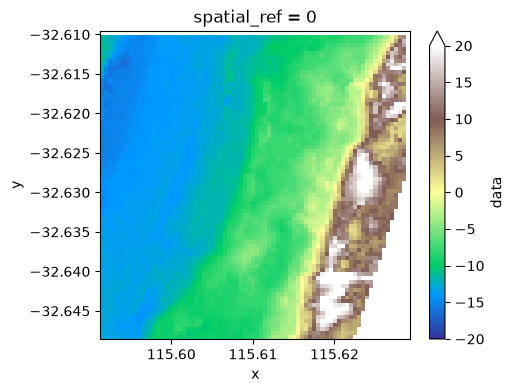

In [4]:
from rompy_xbeach.source import SourceXYZ

source = SourceXYZ(
    filename=DATA_DIR / "bathy_xyz.zip",
    crs=4326,
    res=0.0005,
    xcol="easting",
    ycol="northing",
    zcol="elevation",
    read_csv_kwargs={"sep": "\t"},
)
ds = source.open()
ds.data.plot(cmap="terrain", vmin=-20, vmax=20, figsize=(5, 4))
plt.show()

### Intake catalogues

An intake catalogue lists datasets by name, so configurations can refer to data
without hard-coding file paths.

In [5]:
from rompy_xbeach.source import SourceCRSIntake

print((DATA_DIR / "catalog.yaml").read_text())

sources:
    bathy_netcdf:
        driver: netcdf
        description: Test bathy in NetCDF format
        args:
            urlpath: '{{CATALOG_DIR}}/bathy.nc'
            engine: "netcdf4"
    bathy_geotiff:
        driver: netcdf
        description: Test bathy in GeoTIFF format
        args:
            urlpath: '{{CATALOG_DIR}}/bathy.tif'
            xarray_kwargs:
                engine: rasterio



In [6]:
source = SourceCRSIntake(
    catalog_uri=DATA_DIR / "catalog.yaml", dataset_id="bathy_netcdf", crs=4326
)
print(dict(source.open().sizes))

{'y': 180, 'x': 176}


### An xarray dataset in memory

Useful when data has been downloaded or pre-processed in the same script. This source
cannot be written to YAML, since the data lives only in memory.

In [7]:
from rompy_xbeach.source import SourceCRSDataset

in_memory = xr.open_dataset(DATA_DIR / "bathy.nc")
source = SourceCRSDataset(obj=in_memory, crs=4326)
print(source.open().rio.crs)

EPSG:4326


## 2. Specialised sources

### Wave spectra

`SourceCRSWavespectra` opens spectra with a [wavespectra](https://wavespectra.readthedocs.io)
reader such as `read_ww3`, `read_swan` or `read_era5`. It is used by the
`BoundaryStationSpectra...` classes.

In [8]:
from rompy_xbeach.source import SourceCRSWavespectra

source = SourceCRSWavespectra(
    uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
)
spectra = source.open()
print(dict(spectra.sizes))

{'time': 9, 'site': 19, 'freq': 31, 'dir': 24}


### Tidal constituents

`SourceCRSOceantide` reads tide model constituents with an
[oceantide](https://github.com/oceanum/oceantide) reader, for `TideConsGrid`.
`SourceTideConsPointCSV` reads amplitude and phase per constituent at one site, for
`TideConsPoint`.

In [9]:
from rompy_xbeach.source import SourceCRSOceantide, SourceTideConsPointCSV

cons_dir = DATA_DIR / "swaus_tide_cons"
source = SourceCRSOceantide(
    reader="read_otis_binary",
    kwargs={
        "gfile": cons_dir / "grid_m2s2n2k2k1o1p1q1mmmf",
        "hfile": cons_dir / "h_m2s2n2k2k1o1p1q1mmmf",
        "ufile": cons_dir / "u_m2s2n2k2k1o1p1q1mmmf",
    },
    crs=4326,
)
print("Gridded constituents:", source.open().con.values)

source = SourceTideConsPointCSV(filename=DATA_DIR / "tide_cons_station.csv")
source.open()

Gridded constituents: ['M2' 'S2' 'N2' 'K2' 'K1' 'O1' 'P1' 'Q1' 'MM' 'MF']


<xarray.Dataset> Size: 320B
Dimensions:  (con: 10)
Coordinates:
  * con      (con) <U4 160B 'M2' 'S2' 'N2' 'K2' 'K1' 'O1' 'P1' 'Q1' 'MM' 'MF'
Data variables:
    h        (con) complex128 160B (0.018999999842540936+0.03799999832062555j...

## 3. Timeseries without coordinates

The `...Point` forcing classes take a single timeseries, such as a buoy record. These
sources come from rompy and need no CRS.

In [10]:
from rompy.core.source import SourceTimeseriesCSV

source = SourceTimeseriesCSV(filename=DATA_DIR / "wind.csv", tcol="time")
source.open()

<xarray.Dataset> Size: 1kB
Dimensions:  (time: 25)
Coordinates:
  * time     (time) datetime64[us] 200B 2023-01-01 ... 2023-01-02
Data variables:
    u10      (time) float64 200B -3.634 -3.476 -3.083 ... -5.894 -6.366 -6.693
    v10      (time) float64 200B 6.261 6.246 6.411 6.792 ... 6.306 6.253 6.247
    wspd     (time) float64 200B 7.239 7.148 7.113 7.274 ... 8.632 8.923 9.155
    wdir     (time) float64 200B 149.9 150.9 154.3 159.0 ... 136.9 134.5 133.0

`SourceTimeseriesDataFrame` wraps a pandas dataframe with a time index. It is
provided by the `rompy-binary-datasources` package, installed with
`pip install rompy-xbeach[extra]`.

In [11]:
from rompy_binary_datasources.source import SourceTimeseriesDataFrame

df = pd.read_csv(DATA_DIR / "ssh.csv", index_col="time", parse_dates=True)
source = SourceTimeseriesDataFrame(obj=df)
source.open()

<xarray.Dataset> Size: 400B
Dimensions:  (time: 25)
Coordinates:
  * time     (time) datetime64[us] 200B 2023-01-01 ... 2023-01-02
Data variables:
    ssh      (time) float64 200B -0.6052 -0.4818 -0.3333 ... -0.997 -0.849

## Summary

- Gridded sources carry a CRS, so data in any projection can be interpolated onto the
  XBeach grid.
- Wave spectra and tidal constituents have dedicated sources.
- Plain timeseries use the rompy CSV or dataframe sources.

**See also:** [Data selection options](data_selection.ipynb) controls which part of a
source is used.